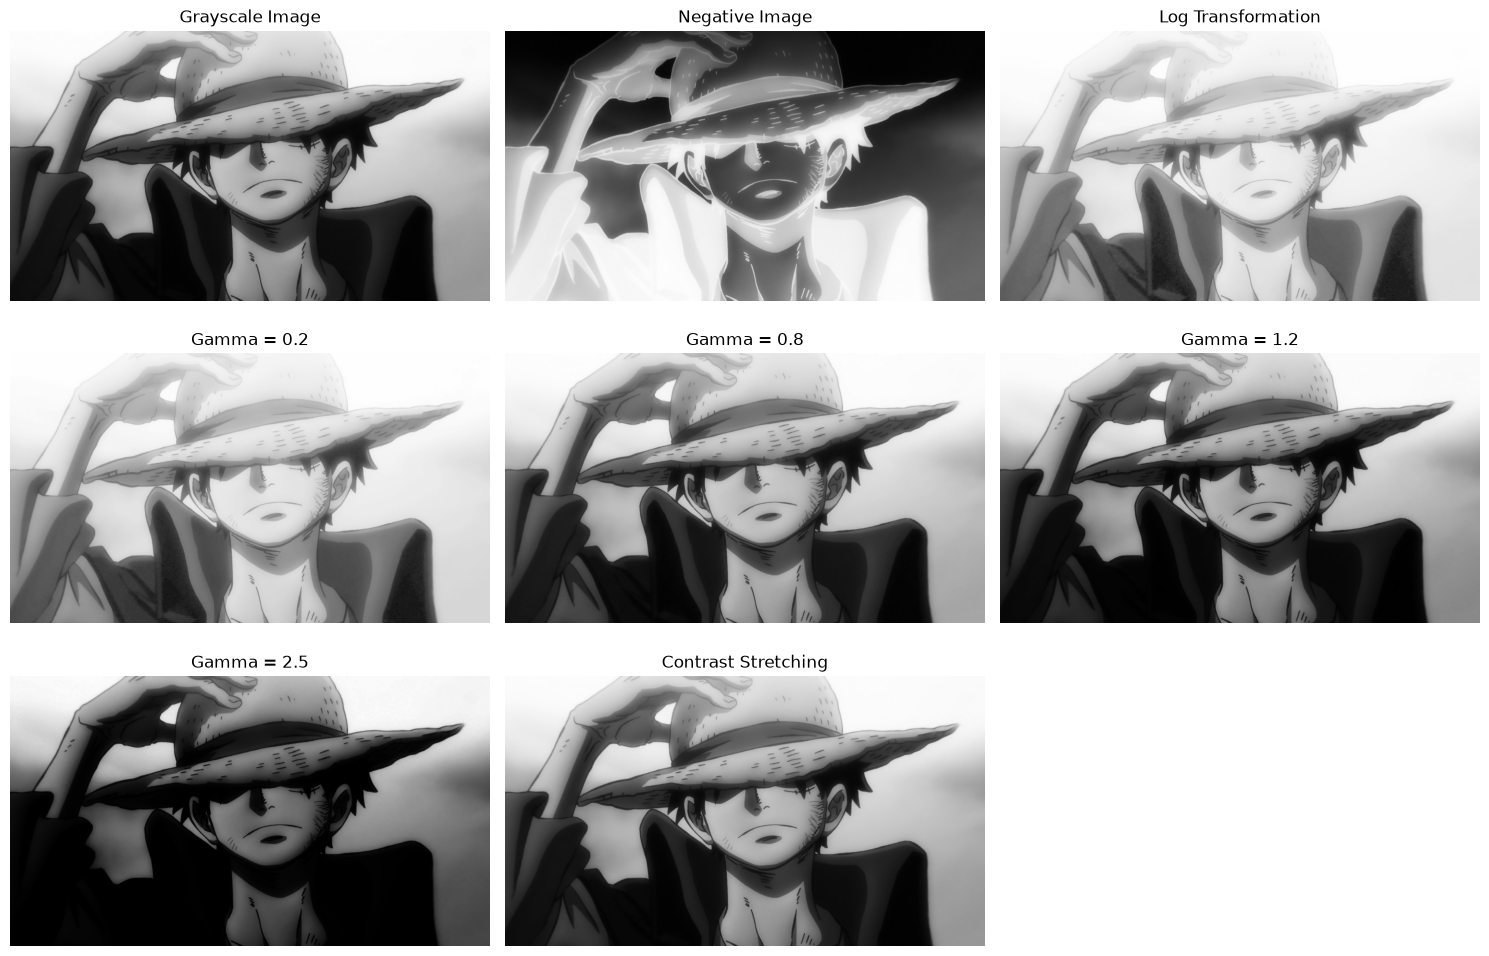

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("luffy.jpg")

if image is None:
    print("Error: Image not found.")
    exit()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2.imwrite("grayscale_image.jpg", gray)

negative = 255 - gray
cv2.imwrite("negative_image.jpg", negative)

gray_float = gray.astype(np.float32)
c = 255 / np.log(1 + np.max(gray_float))
log_transform = c * np.log(1 + gray_float)
log_transform = np.uint8(log_transform)
cv2.imwrite("log_transformed_image.jpg", log_transform)

normalized = gray / 255.0

gamma_values = [0.2, 0.8, 1.2, 2.5]
gamma_images = []

for gamma in gamma_values:
    gamma_image = np.uint8(255 * (normalized ** gamma))
    gamma_images.append(gamma_image)
    cv2.imwrite(f"gamma_{gamma}.jpg", gamma_image)

r_min = np.min(gray)
r_max = np.max(gray)

contrast_stretched = ((gray - r_min) /
                      (r_max - r_min) * 255)

contrast_stretched = np.uint8(contrast_stretched)
cv2.imwrite("contrast_stretched_image.jpg", contrast_stretched)

plt.figure(figsize=(15, 10))

images = [
    gray,
    negative,
    log_transform,
    gamma_images[0],
    gamma_images[1],
    gamma_images[2],
    gamma_images[3],
    contrast_stretched
]

titles = [
    "Grayscale Image",
    "Negative Image",
    "Log Transformation",
    "Gamma = 0.2",
    "Gamma = 0.8",
    "Gamma = 1.2",
    "Gamma = 2.5",
    "Contrast Stretching"
]

for i in range(8):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()
